# Week One Task-1 Exploratory Data Analysis (EDA)

# Imports from Modules

In [2]:
import os
import sys

# Get the current working directory (notebooks folder)
notebooks_dir = os.getcwd()

# Construct the path to the scripts folder
scripts_path = os.path.join(notebooks_dir, '..', 'scripts')

# Add the scripts folder to the system path
sys.path.append(scripts_path)

In [3]:
from importlib import reload
import analysis, data_visualization
reload(analysis)
reload(data_visualization)

<module 'data_visualization' from 'c:\\Users\\hp\\Desktop\\KIAM\\WEEK ONE\\Week 2\\10-academy-kaim-week1\\notebooks\\..\\scripts\\data_visualization.py'>

In [4]:
import imports
from data_loader import load_csv_data
from analysis import  check_missing_value, headline_length_check, count_and_sort, convert_date, extract_date, perform_sentiment_analysis, nlp_keyword_topic_analysis, extract_keywords, analyze_top_publishers, classify_article_topic
from data_visualization import plot_univarate, plot_trends

In [6]:
file_path = r"C:\Users\hp\Desktop\KIAM\WEEK ONE\TechnicalContent\Technical Content\Data\raw_analyst_ratings.csv\raw_analyst_ratings.csv"
data = load_csv_data (file_path)
data.head()

,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


# 1. Data Check and Cleaning

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1407328 entries, 0 to 1407327
Data columns (total 6 columns):
 #   Column      Non-Null Count    Dtype 
---  ------      --------------    ----- 
 0   Unnamed: 0  1407328 non-null  int64 
 1   headline    1407328 non-null  object
 2   url         1407328 non-null  object
 3   publisher   1407328 non-null  object
 4   date        1407328 non-null  object
 5   stock       1407328 non-null  object
dtypes: int64(1), object(5)
memory usage: 64.4+ MB


In [8]:
# check for missing values
check_missing_value(data)

Missing Value Summary


Unnamed: 0    0
headline      0
url           0
publisher     0
date          0
stock         0
dtype: int64

# 2. Descriptive Statistics:

### 2.1 Obtain basic statistics for textual lengths (like headline length).

In [9]:
headline_length_check(data, 'headline')

Headline Length Statistics


count    1.407328e+06
mean     7.312051e+01
std      4.073531e+01
min      3.000000e+00
25%      4.700000e+01
50%      6.400000e+01
75%      8.700000e+01
max      5.120000e+02
Name: headline_length, dtype: float64

In [10]:
data.head(2)

,Unnamed: 0,headline,url,publisher,date,stock,headline_length
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A,39
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A,42


### 2.2 Plot Headline length in histogram

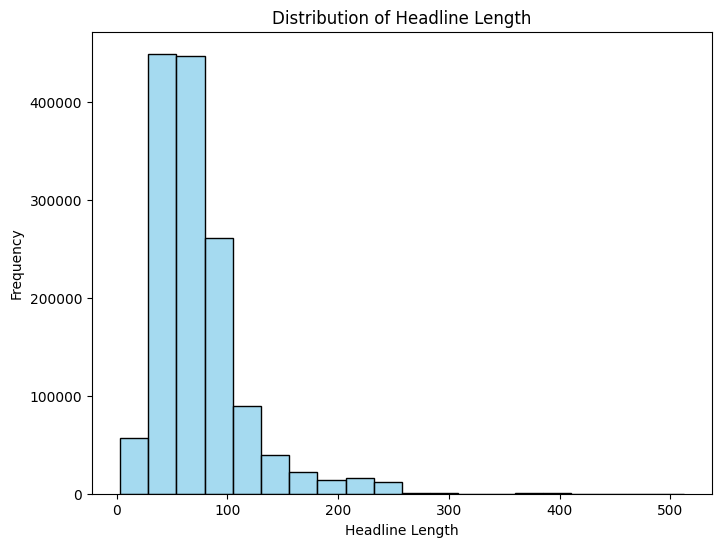

In [11]:
plot_univarate(data, 'headline_length', 'Distribution of Headline Length', 'Headline Length', figsize=(8,6))

### 2.3 Count the number of articles per publisher to identify which publishers are most active.


In [12]:
count_and_sort(data, 'publisher')

publisher
Stock Market Newz                    1
Miri Segal                           1
mjintertrader                        1
adam@eosdetroit.io                   1
Scout Finance Editorial Team         1
                                 ...  
Monica Gerson                    82380
Charles Gross                    96732
Benzinga Newsdesk               150484
Lisa Levin                      186979
Paul Quintaro                   228373
Name: count, Length: 1034, dtype: int64

### 2.4 Analyze the publication dates to see trends over time, such as increased news frequency on particular days or during specific events.

####  2.4.1 preprocess the data to ensure both date formats are correctly parsed into a unified datetime column.

In [13]:
convert_date(data, 'date')

,Unnamed: 0,headline,url,publisher,date,stock,headline_length
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 14:30:54+00:00,A,39
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 14:45:20+00:00,A,42
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 08:30:07+00:00,A,29
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 16:45:06+00:00,A,44
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 15:38:59+00:00,A,87
5,5,"CFRA Maintains Hold on Agilent Technologies, L...",https://www.benzinga.com/news/20/05/16095163/c...,vishwanath@benzinga.com,2020-05-22 15:23:25+00:00,A,71
6,6,"UBS Maintains Neutral on Agilent Technologies,...",https://www.benzinga.com/news/20/05/16094027/u...,vishwanath@benzinga.com,2020-05-22 13:36:20+00:00,A,73
7,7,Agilent Technologies shares are trading higher...,https://www.benzinga.com/wiim/20/05/16093805/a...,Benzinga Newsdesk,2020-05-22 13:07:04+00:00,A,120
8,8,Wells Fargo Maintains Overweight on Agilent Te...,https://www.benzinga.com/news/20/05/16093505/w...,vishwanath@benzinga.com,2020-05-22 12:37:59+00:00,A,84
9,9,10 Biggest Price Target Changes For Friday,https://www.benzinga.com/analyst-ratings/price...,Lisa Levin,2020-05-22 12:06:17+00:00,A,42


In [14]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1407328 entries, 0 to 1407327
Data columns (total 7 columns):
 #   Column           Non-Null Count    Dtype              
---  ------           --------------    -----              
 0   Unnamed: 0       1407328 non-null  int64              
 1   headline         1407328 non-null  object             
 2   url              1407328 non-null  object             
 3   publisher        1407328 non-null  object             
 4   date             1407328 non-null  datetime64[ns, UTC]
 5   stock            1407328 non-null  object             
 6   headline_length  1407328 non-null  int64              
dtypes: datetime64[ns, UTC](1), int64(2), object(4)
memory usage: 75.2+ MB


#### 2.4.2 Extract time features, Analyze trends over time, Count articles by day, Count articles by year and month....

In [15]:
extract_date(data, 'date')

,date,year,month,day,day_of_week
0,2020-06-05 14:30:54+00:00,2020,6,5,Friday
1,2020-06-03 14:45:20+00:00,2020,6,3,Wednesday
2,2020-05-26 08:30:07+00:00,2020,5,26,Tuesday
3,2020-05-22 16:45:06+00:00,2020,5,22,Friday
4,2020-05-22 15:38:59+00:00,2020,5,22,Friday


In [16]:
data.head(2)

,Unnamed: 0,headline,url,publisher,date,stock,headline_length,year,month,day,day_of_week
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 14:30:54+00:00,A,39,2020,6,5,Friday
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 14:45:20+00:00,A,42,2020,6,3,Wednesday


In [17]:
# Analyze trends over time
# Count articles by day
daily_counts = data.groupby('date').size()

# Count articles by month
monthly_counts = data.groupby(['year', 'month']).size()

# Count articles by year
yearly_count = data.groupby(['year']).size()

# Count articles by day of the week
weekday_counts = data['day_of_week'].value_counts()


**Visualizations**

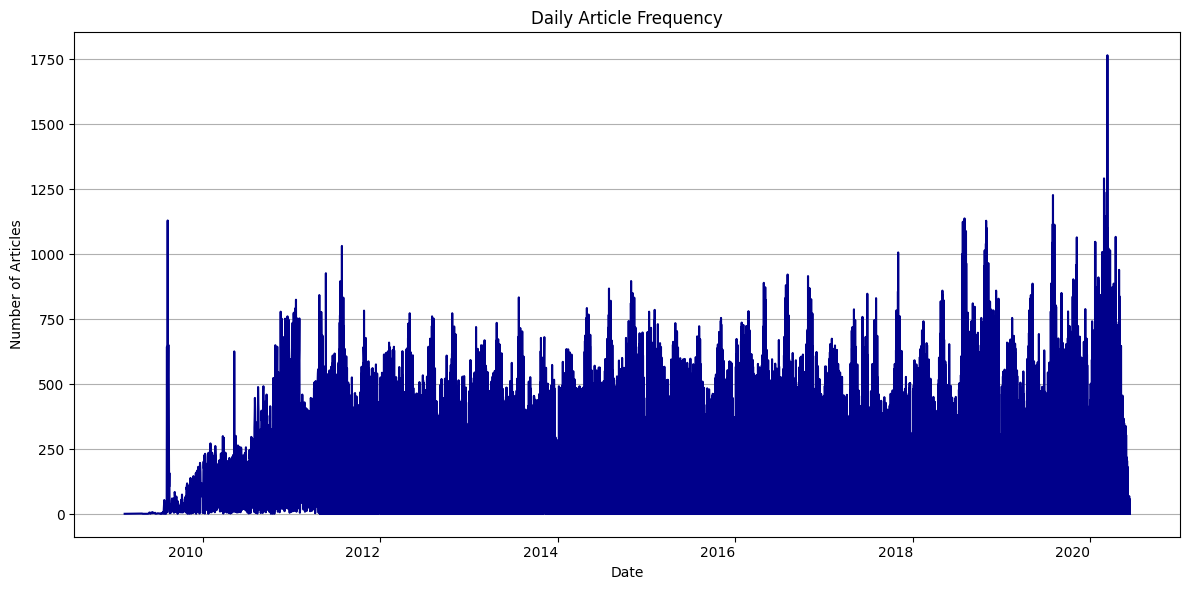

In [18]:
# Daily Trend
plot_trends(
    data=daily_counts,
    title="Daily Article Frequency",
    x_label="Date",
    y_label="Number of Articles",
    plot_type='line',
    figsize=(12, 6),
    color='darkblue'
)

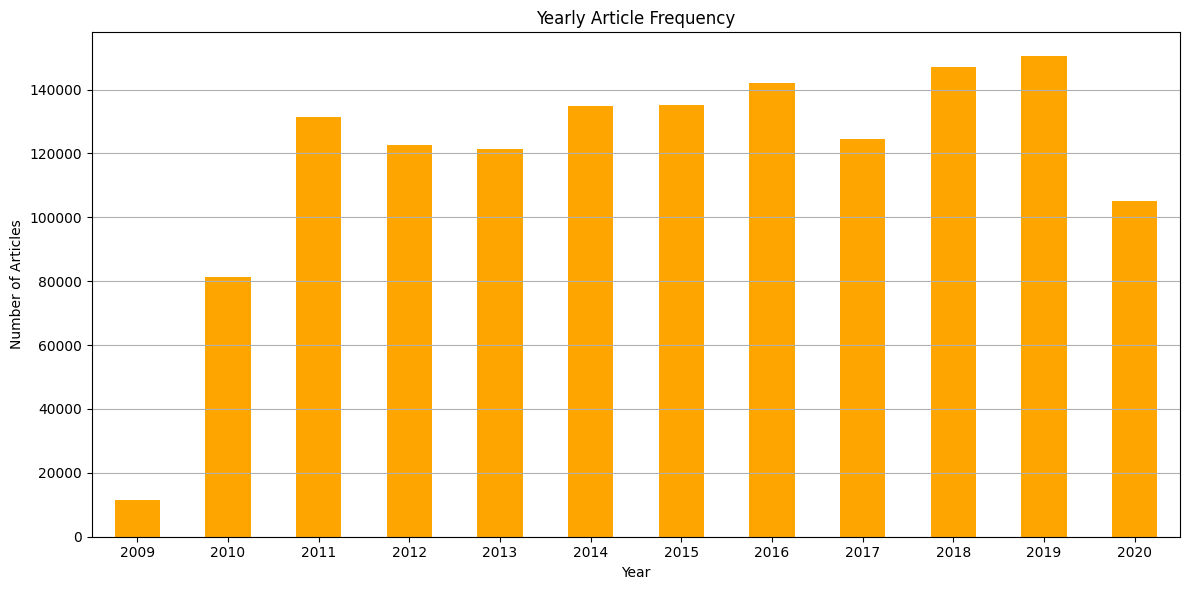

In [19]:
# Yearly trends
plot_trends(
    data=yearly_count,
    title="Yearly Article Frequency",
    x_label="Year",
    y_label="Number of Articles",
    plot_type='bar',
    figsize=(12, 6),
    color='orange'
)


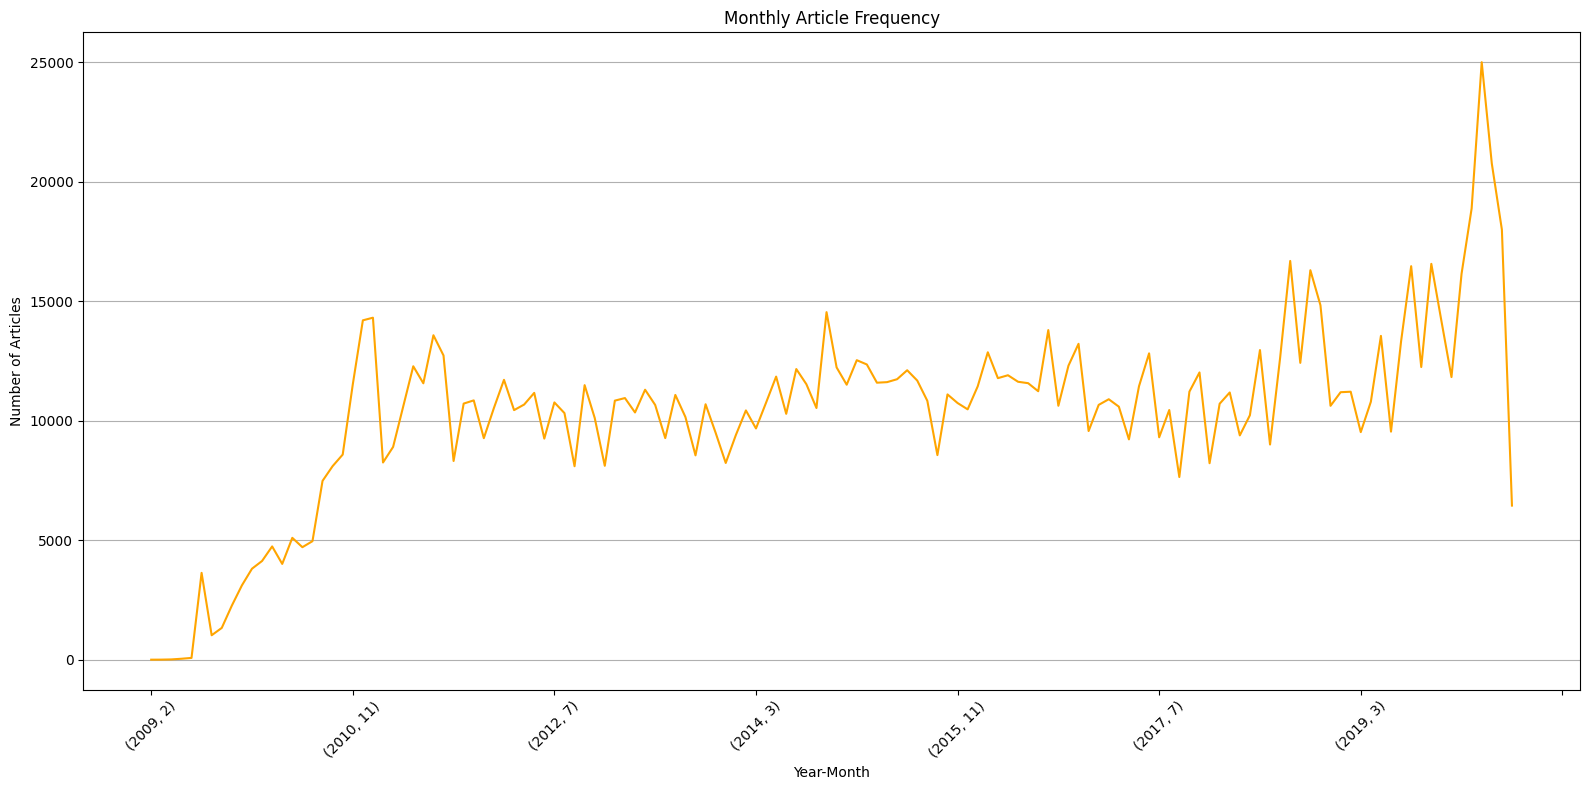

In [20]:
# Monthly Triend
plot_trends(
    data=monthly_counts,
    title="Monthly Article Frequency",
    x_label="Year-Month",
    y_label="Number of Articles",
    plot_type='line',
    figsize=(16, 8),
    color='orange',
    xticks_rotation=45
)

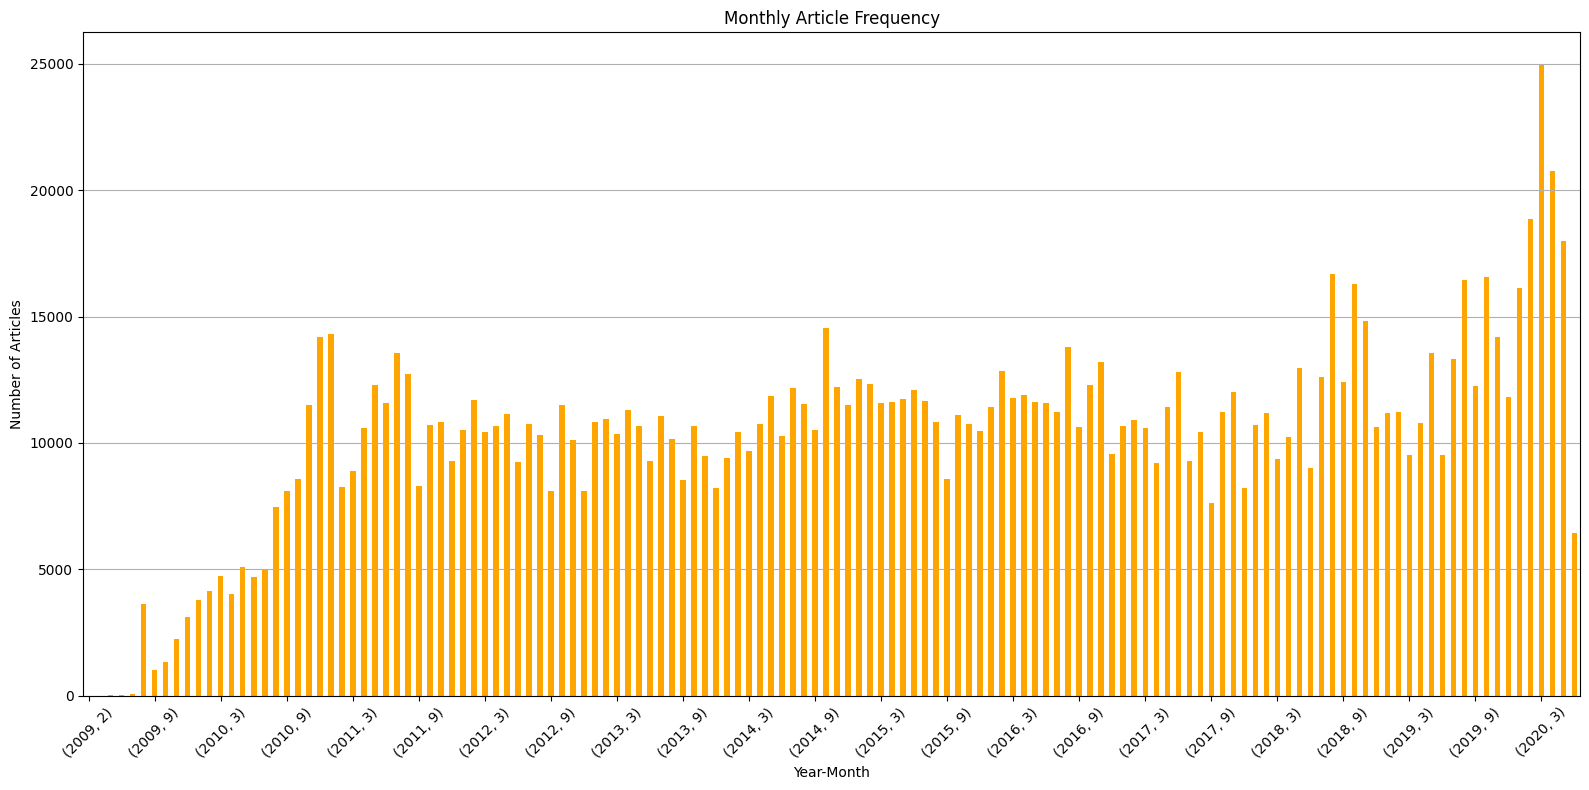

In [21]:
# Bar plot with reduced x-axis labels
plot_trends(
    data=monthly_counts,
    title="Monthly Article Frequency",
    x_label="Year-Month",
    y_label="Number of Articles",
    plot_type='bar',
    figsize=(16, 8),
    color='orange',
    xticks_rotation=45,
    reduce_xticks=True,
    xticks_step=6  # Show every 6th label
)


# 3 Text Analysis(Sentiment analysis & Topic Modeling)

## 3.1 Perform sentiment analysis on headlines to gauge the sentiment 

In [22]:
data_with_sentiment = perform_sentiment_analysis(data, text_column='headline')

# View a sample of the results
print(data_with_sentiment[['headline', 'compound', 'sentiment_label']].head())

                                            headline  compound sentiment_label
0            Stocks That Hit 52-Week Highs On Friday     0.000         neutral
1         Stocks That Hit 52-Week Highs On Wednesday     0.000         neutral
2                      71 Biggest Movers From Friday     0.000         neutral
3       46 Stocks Moving In Friday's Mid-Day Session     0.000         neutral
4  B of A Securities Maintains Neutral on Agilent...     0.296        positive


## 3.2 Use natural language processing to identify common keywords or phrases

In [23]:

#nlp_keyword_topic_analysis(data, text_column='headline') # takes time so i used the following
keywords = extract_keywords(data, text_column='headline')
print("Keywords:", keywords)

Keywords: ['announces' 'benzinga' 'buy' 'downgrades' 'earnings' 'eps' 'est' 'market'
 'mid' 'price' 'pt' 'raises' 'reports' 'sales' 'shares' 'stocks' 'trading'
 'update' 'vs' 'week']


# 4. Time Series Analysis done on Section 2 Discriptive Statistcs

# 5. Publisher Analysis

#### 5.1 Which publishers contribute most to the news feed? 

In [24]:
top_publishers = analyze_top_publishers(data, publisher_column='publisher', n=10)
print(top_publishers)

publisher
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Name: count, dtype: int64


### 5.2 Is there a difference in the type of news they report?

In [25]:
classified_data = classify_article_topic(data, 'headline')
publisher_topic_counts = classified_data.groupby(['publisher', 'topic']).size().unstack()

In [26]:
print(publisher_topic_counts)

topic                       finance  health    other  technology
publisher                                                       
47ertrends                     18.0     NaN      NaN         NaN
AARP                            NaN     NaN      7.0         NaN
ABNNewswire                     NaN     NaN     11.0         2.0
Aakin                           NaN     NaN      3.0         2.0
Aaron Jackson.Ed                1.0     NaN     15.0         NaN
...                             ...     ...      ...         ...
vic@forextraininggroup.com      NaN     NaN      1.0         NaN
vishwanath@benzinga.com        35.0    21.0     40.0      1734.0
vivek.proactive@gmail.com       6.0     1.0      NaN       113.0
wallstreet1928                  2.0     NaN      3.0         3.0
webmaster                    2103.0   301.0  12715.0      5194.0

[1034 rows x 4 columns]


#### 5.3 If email addresses are used as publisher names, identify unique domains to see if certain organizations contribute more frequently

In [27]:
data['domain'] = data['publisher'].str.split('@').str[1]
unique_domains = data['domain'].unique()


In [ ]:
domain_counts = data['domain'].value_counts()
print(domain_counts)


domain
benzinga.com              7937
gmail.com                  139
andyswan.com                 5
investdiva.com               2
tothetick.com                2
eosdetroit.io                1
forextraininggroup.com       1
stockmetrix.net              1
Name: count, dtype: int64


: 